In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("Summary_of_Results_3_18_2026.csv")

In [21]:
df.head()

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,YEAR,STATE
0,13797.0,NM,"TAYLOR, NE",1653.0,1985-05-31,2466,1000,BANK OF TAYLOR,14542.0,13360.0,FAILURE,PA,FDIC,1985,NE
1,18388.0,NM,"FAIRFIELD, NE",1656.0,1985-05-31,6571,1001,FAIRFIELD STATE BANK,6795.0,6034.0,FAILURE,PO,FDIC,1985,NE
2,18738.0,NM,"EDGAR, NE",1118.0,1985-05-31,2469,1002,SECURITY STATE BANK,6570.0,6072.0,FAILURE,PA,FDIC,1985,NE
3,19117.0,NM,"OAK, NE",165.0,1985-05-31,6570,1003,SCROGGIN & COMPANY BANK,3552.0,3219.0,FAILURE,PO,FDIC,1985,NE
4,30965.0,SL,"SAN DIEGO, CA",327146.0,1985-05-31,1706,1004,CENTRAL S&LA,2308903.0,1680711.0,ASSISTANCE,A/A,FSLIC,1985,CA


In [16]:
df.columns

Index(['CERT', 'CHCLASS1', 'CITYST', 'COST', 'FAILDATE', 'FIN', 'ID', 'NAME',
       'QBFASSET', 'QBFDEP', 'RESTYPE', 'RESTYPE1', 'SAVR', 'YEAR', 'STATE'],
      dtype='object')

## **1. NAME**  
**What it is:** The bank’s official name.  
**Values:** Text (e.g., *“Silicon Valley Bank”*, *“Signature Bank”*).

---

## **2. CERT**  
**What it is:** FDIC Certificate Number — a unique ID for each bank.  
**Values:** Integer (e.g., 24735, 32519).  
**Notes:** Rarely missing.

---

## **3. CITYST**  
**What it is:** City + State of the bank’s headquarters.  
**Values:** Text like `"New York, NY"` or `"Dallas, TX"`.  
**Notes:** You can extract the state using `str[-2:]`.

---

## **4. COST**  
**What it is:** Cost of resolving the bank failure (to the FDIC).  
**Values:** Numeric, often large (millions to billions).  
**Notes:** **116 missing values** — important for LGD.

---

## **5. FAILDATE**  
**What it is:** The date the bank officially failed.  
**Values:** Dates like `"2023-03-10"`.  
**Notes:** Convert to datetime.

---

## **6. FIN**  
**What it is:** FDIC Failure Identification Number.  
**Values:** Integer (unique per failure).  
**Notes:** Internal FDIC tracking code.

---

## **7. ID**  
**What it is:** Internal FDIC dataset ID.  
**Values:** Integer.  
**Notes:** Not analytically important.

---

## **8. QBFASSET**  
**What it is:** Total assets of the bank at failure.  
**Values:** Numeric (often very large).  
**Notes:** Must be **> 0** for LGD.

---

## **9. QBFDEP**  
**What it is:** Total deposits at failure.  
**Values:** Numeric.  
**Notes:** Only 1 missing value.

---

## **10. RESTYPE**  
**What it is:** High‑level resolution category.  
**Values you will see:**  
- **FAILURE** → the bank failed (almost always this)

---

## **11. RESTYPE1**  
**What it is:** Specific FDIC resolution method.  
**Common values:**  
- **PA** = Purchase & Assumption (another bank buys it)  
- **PO** = Payout (FDIC pays depositors directly)  
- **PI** = Insured-only P&A  
- **IDT** = Insured Deposit Transfer  
- **OBA** = Open Bank Assistance (rare)

These values matter for predicting cost.

---

## **12. CHCLASS1**  
**What it is:** Bank charter class (legal/regulatory type).  
**Common values:**  
- **N** = National Bank  
- **SM** = State Member Bank  
- **NM** = State Non‑Member Bank  
- **SA** = State Savings Association  
- **SB** = Federal Savings Bank  
- **OI** = Foreign bank branch  

This feature is useful for modeling.

---

## **13. SAVR**  
**What it is:** Insurance fund indicator.  
**Values:**  
- Usually **DIF** (Deposit Insurance Fund)  
- Sometimes blank or other codes for older failures.



In [4]:
# Count NaN values in each column
nan_counts = df.isna().sum().sort_values(ascending=False)

# Optionally: show only columns that actually contain NaN
nan_columns = nan_counts[nan_counts > 0]

print("\nColumns with NaN values:")
print(nan_columns)



Columns with NaN values:
COST        116
CERT          2
QBFASSET      2
QBFDEP        1
dtype: int64




# **Instead of predicting COST directly…**

predicting a *ratio* called **LGD (Loss Given Default)**:   LGD = COST\QBFASSET

Why?

Because:

- COST alone depends heavily on bank size  
- A $1B bank failing is not the same as a $50M bank failing  
- Ratios normalize the data  
- Models usually perform better on normalized targets  

So instead of predicting:

> “How many dollars will this bank failure cost?”

You predict:

> “What percentage of the bank’s assets will be lost?”


## PHASE 0 — Exploratory Data Analysis (EDA)

In [5]:
print(df.shape)
print(df.dtypes)

(3592, 13)
CERT        float64
CHCLASS1     object
CITYST       object
COST        float64
FAILDATE     object
FIN           int64
ID            int64
NAME         object
QBFASSET    float64
QBFDEP      float64
RESTYPE      object
RESTYPE1     object
SAVR         object
dtype: object


In [6]:
#Numerical columns
df.describe()

,CERT,COST,FIN,ID,QBFASSET,QBFDEP
count,3590.000000,3.476000e+03,3592.000000,3592.000000,3.590000e+03,3.591000e+03
mean,24623.933148,8.463684e+04,4788.970212,2318.500000,1.504671e+06,8.607555e+05
std,11663.263089,5.264909e+05,3134.641832,1037.065411,3.284273e+07,1.733422e+07
min,40.000000,-1.138100e+04,0.000000,523.000000,5.070000e+02,0.000000e+00
25%,18372.250000,3.151500e+03,2263.750000,1420.750000,2.482875e+04,2.419650e+04
50%,26472.000000,1.131500e+04,4258.500000,2318.500000,6.988650e+04,6.782100e+04
75%,31032.250000,4.290175e+04,7163.250000,3216.250000,2.235608e+05,2.065930e+05
max,91189.000000,1.895962e+07,11919.000000,4114.000000,1.471631e+09,9.546776e+08


### **A bank can fail even if COST < 0**  
Failure is defined by **the bank itself**, not by the FDIC’s profit or loss.

A bank fails when:

- it cannot meet obligations  
- it becomes insolvent  
- regulators close it for safety reasons  
- another bank must take over deposits  

This has **nothing to do** with whether the FDIC later makes or loses money during the cleanup.



### FDIC accounting is “net cost,” not “loss”  
COST = payouts − recoveries  
If recoveries > payouts → COST becomes negative.

This is an accounting outcome, not a sign of bank health.

**A bank can fail even if COST is negative because COST measures the FDIC’s net recovery, not the bank’s financial health.**



In [7]:
#Categorical columns
df.describe(include='object')

,CHCLASS1,CITYST,FAILDATE,NAME,RESTYPE,RESTYPE1,SAVR
count,3592,3592,3592,3592,3592,3592,3592
unique,7,2021,1419,3261,2,11,6
top,NM,"HOUSTON, TX",4/20/1988,FIRST STATE BANK,FAILURE,PA,FDIC
freq,1192,102,60,22,3001,2105,1122


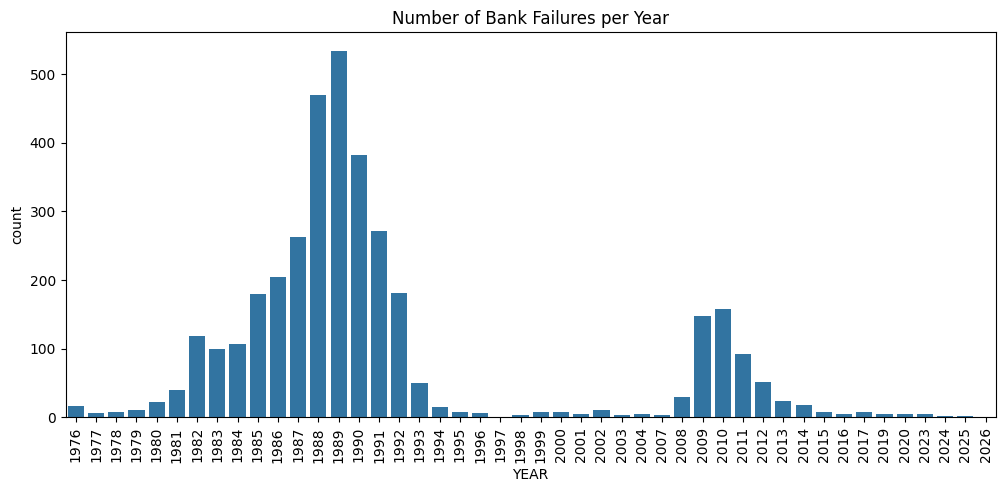

In [8]:
# 4. Distribution of Failures Over Time
import matplotlib.pyplot as plt
import seaborn as sns
df['FAILDATE'] = pd.to_datetime(df['FAILDATE'], errors='coerce')
df['YEAR'] = df['FAILDATE'].dt.year

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='YEAR')
plt.xticks(rotation=90)
plt.title("Number of Bank Failures per Year")
plt.show()


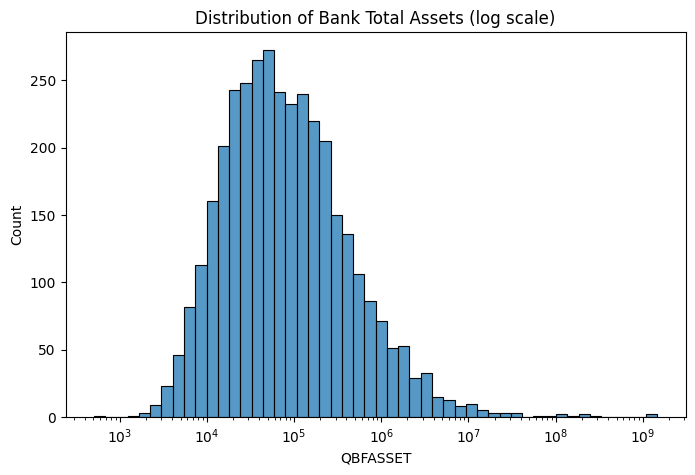

In [9]:
#Distribution of Total Assets (QBFASSET)
plt.figure(figsize=(8,5))
sns.histplot(df['QBFASSET'], bins=50, log_scale=True)
plt.title("Distribution of Bank Total Assets (log scale)")
plt.show()


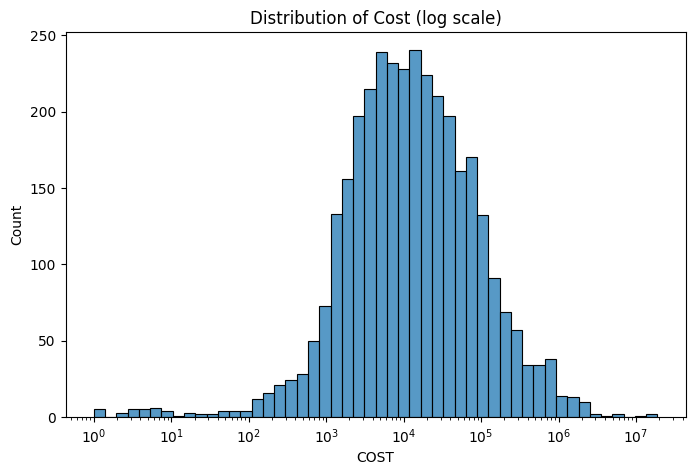

In [22]:
#Distribution of COST
plt.figure(figsize=(8,5))
sns.histplot(df['COST'], bins=50, log_scale=True)
plt.title("Distribution of Cost (log scale)")
plt.show()


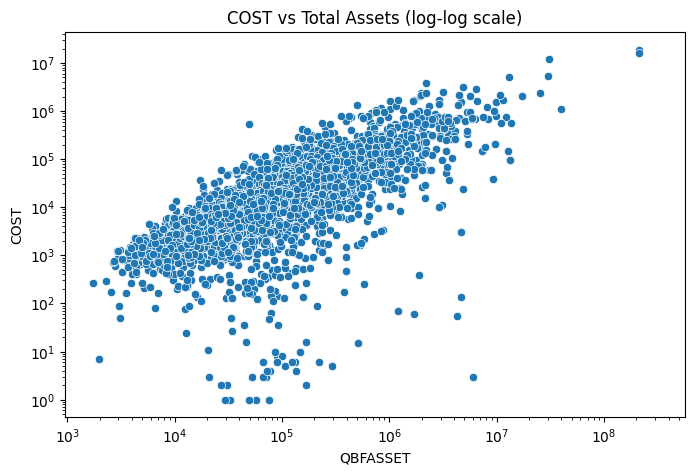

In [11]:
#Relationship between Total Assets and COST
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='QBFASSET', y='COST')
plt.xscale('log')
plt.yscale('log')
plt.title("COST vs Total Assets (log-log scale)")
plt.show()


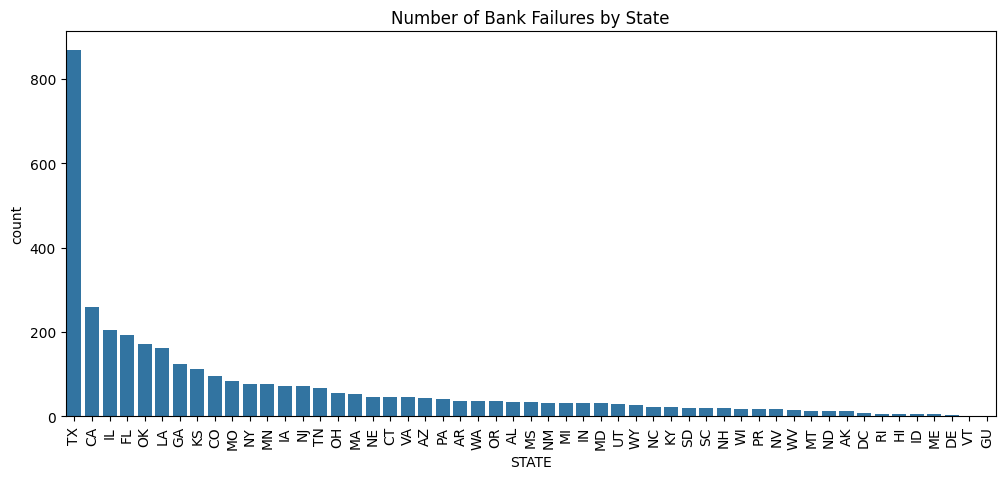

In [12]:
#Failure by State
df['STATE']= df['CITYST'].str[-2:]
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='STATE', order=df['STATE'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Number of Bank Failures by State")
plt.show()


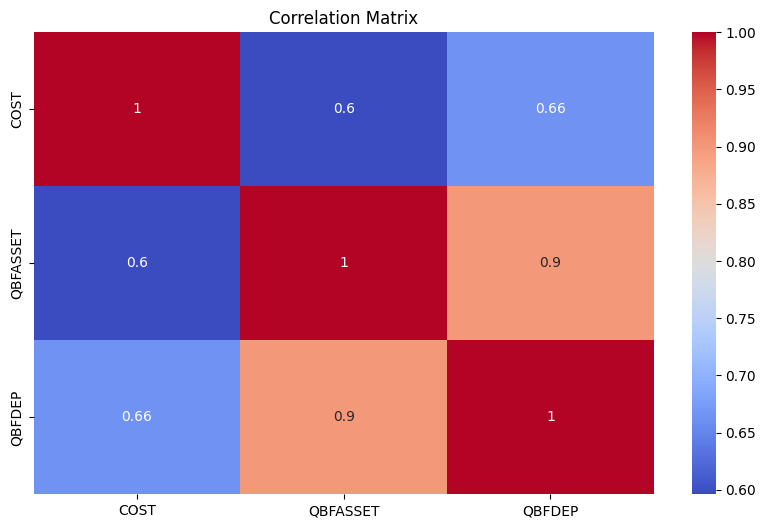

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['COST','QBFASSET','QBFDEP']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


| Pair | Correlation | Meaning |
|------|-------------|---------|
| **QBFASSET ↔ QBFDEP = 0.90** | Very strong | Bigger banks have more deposits. Makes perfect sense. |
| **COST ↔ QBFDEP = 0.66** | Strong | Banks with more deposits tend to cost more when they fail. |
| **COST ↔ QBFASSET = 0.60** | Moderate–strong | Larger banks cost more to resolve. |



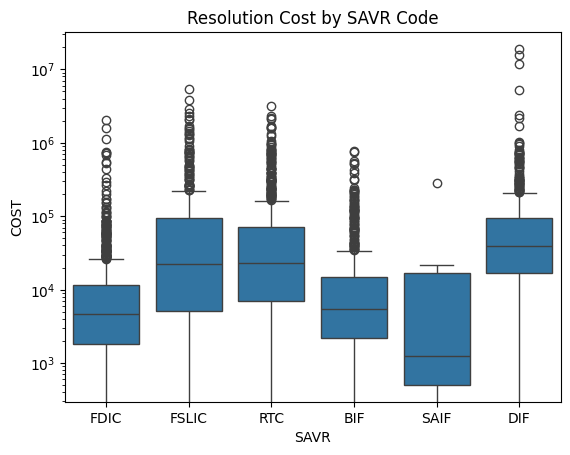

In [14]:
sns.boxplot(data=df, x='SAVR', y='COST')
plt.yscale('log')
plt.title("Resolution Cost by SAVR Code")
plt.show()


### 1. **Different SAVR codes have different cost profiles**  
Some funds (like FSLIC or RTC) show **higher medians** or **larger spreads**, meaning failures during those eras were more expensive.

### 2. **DIF (modern fund) has a wide range**  
Modern failures vary a lot — some small, some extremely costly.

### 3. **Historical funds (FSLIC, RTC) often show higher costs**  
This reflects the **Savings & Loan crisis** of the 1980s–1990s, which was extremely expensive.

### 4. **SAVR is a meaningful feature**  
Because different insurance funds correspond to different eras and failure types, SAVR captures **historical patterns** that influence COST and LGD.

